In [3]:
# =========================================
# Core Data Handling & Computation
# =========================================
import pandas as pd
import numpy as np

# =========================================
# Visualization Utilities
# =========================================
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# Machine Learning - Core Workflow
# =========================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

# =========================================
# Models (Baseline + Ensemble + Boosting)
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================================
# Evaluation Framework
# =========================================
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

# =========================================
# Imbalance Handling Strategy
# =========================================
from imblearn.over_sampling import SMOTE

# =========================================
# Model Interpretability
# =========================================
import shap

In [4]:
#pip install shap --upgrade

# Load Dataset

In [5]:
df = pd.read_csv("drug_regulatory_classification_dataset (1).csv")

# Dataset Analysis

In [6]:
df.head(10)

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug
5,100,104.86,52.54,447139.11,1,3.93,3.38,0.90,40.95,59.05,...,North,Yes,No,No,44.35,77.85,0.40,8.88,0.45,Regulated Drug
6,200,178.58,127.63,120901.34,1,5.26,5.70,0.41,49.77,50.23,...,South,Yes,No,No,53.70,17.81,49.12,4.45,0.38,Non-Regulated Drug
7,200,12.11,8.65,186032.33,4,8.48,3.84,0.82,13.48,86.52,...,South,No,No,No,68.97,26.23,6.40,6.47,0.55,Regulated Drug
8,200,267.44,164.15,238968.98,2,2.91,3.20,0.18,9.32,90.68,...,West,No,No,No,94.36,70.04,17.25,1.29,0.68,Non-Regulated Drug
9,500,144.07,58.21,329718.92,1,3.95,1.75,0.11,40.67,59.33,...,East,No,Yes,No,70.13,1.08,35.70,5.61,0.32,Non-Regulated Drug


In [7]:
df.shape

(60000, 30)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         60000 non-null  int64  
 1   Price_Per_Unit                    60000 non-null  float64
 2   Production_Cost                   60000 non-null  float64
 3   Marketing_Spend                   60000 non-null  float64
 4   Clinical_Trial_Phase              60000 non-null  int64  
 5   Side_Effect_Severity_Score        60000 non-null  float64
 6   Abuse_Potential_Score             60000 non-null  float64
 7   Prescription_Rate                 60000 non-null  float64
 8   Hospital_Distribution_Percentage  60000 non-null  float64
 9   Pharmacy_Distribution_Percentage  60000 non-null  float64
 10  Annual_Sales_Volume               60000 non-null  float64
 11  Regulatory_Risk_Score             60000 non-null  float64
 12  Appr

In [9]:
float_cols = df.select_dtypes(include="float").columns

In [10]:
float_cols

Index(['Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Side_Effect_Severity_Score', 'Abuse_Potential_Score',
       'Prescription_Rate', 'Hospital_Distribution_Percentage',
       'Pharmacy_Distribution_Percentage', 'Annual_Sales_Volume',
       'Regulatory_Risk_Score', 'R&D_Investment_Million',
       'Insurance_Coverage_Percentage', 'Export_Percentage',
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')

In [11]:
df.describe()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Patent_Duration_Years,R&D_Investment_Million,Competitor_Count,Recall_History_Count,Adverse_Event_Reports,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
count,60000.000000,60000.000000,60000.000000,6.000000e+04,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,292.434167,253.312360,151.954054,2.669683e+05,2.502750,5.498936,2.847217,0.526119,47.411735,52.588265,...,9.986983,100.536433,11.968967,0.499533,4.996517,59.793295,39.993931,29.900791,5.476783,0.525048
std,214.975937,142.948109,92.028388,1.831812e+05,1.118055,2.604378,1.592573,0.245659,24.529169,24.529169,...,5.459745,57.332576,7.223363,0.708925,2.236252,23.046536,23.107853,17.313127,2.597910,0.244788
min,50.000000,5.020000,2.070000,1.000535e+04,1.000000,1.000000,0.010000,0.100000,5.000000,10.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.010000,1.000000,0.100000
25%,100.000000,129.790000,75.087500,1.335899e+05,2.000000,3.230000,1.610000,0.310000,26.150000,31.480000,...,5.000000,51.070000,6.000000,0.000000,3.000000,39.740000,19.900000,14.860000,3.230000,0.310000
50%,250.000000,252.870000,146.395000,2.583855e+05,3.000000,5.500000,2.630000,0.530000,47.450000,52.550000,...,10.000000,100.750000,12.000000,0.000000,5.000000,59.740000,39.990000,29.990000,5.470000,0.530000
75%,500.000000,377.572500,218.752500,3.819740e+05,4.000000,7.750000,3.880000,0.740000,68.520000,73.850000,...,15.000000,150.170000,18.000000,1.000000,6.000000,79.680000,59.950000,44.800000,7.720000,0.740000
max,650.000000,499.960000,398.290000,1.999699e+06,4.000000,10.000000,9.350000,0.950000,90.000000,95.000000,...,19.000000,200.000000,24.000000,6.000000,16.000000,100.000000,80.000000,60.000000,10.000000,0.950000


In [12]:
df["Target_Regulatory_Class"].value_counts()

Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64

<Axes: xlabel='Target_Regulatory_Class', ylabel='count'>

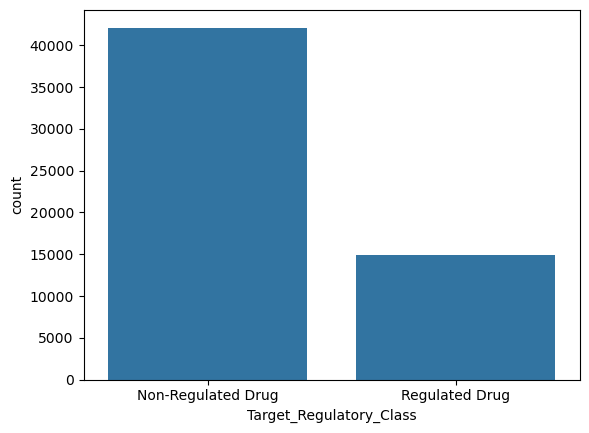

In [13]:
sns.countplot(x="Target_Regulatory_Class", data=df)

The dataset exhibits a moderate class imbalance, with approximately 74% Non-Regulated and 26% Regulated drugs. 

In [14]:
df.isna().sum()

Dosage_mg                              0
Price_Per_Unit                         0
Production_Cost                        0
Marketing_Spend                        0
Clinical_Trial_Phase                   0
Side_Effect_Severity_Score             0
Abuse_Potential_Score                  0
Prescription_Rate                      0
Hospital_Distribution_Percentage       0
Pharmacy_Distribution_Percentage       0
Annual_Sales_Volume                    0
Regulatory_Risk_Score                  0
Approval_Time_Months                   0
Patent_Duration_Years                  0
R&D_Investment_Million                 0
Competitor_Count                       0
Recall_History_Count                   0
Adverse_Event_Reports                  0
Drug_Form                              0
Therapeutic_Class                      0
Manufacturing_Region                   0
Requires_Cold_Storage                  0
OTC_Flag                               0
High_Risk_Substance                    0
Insurance_Covera

I found that there is 3000 missing data in the Target_Regulatory_Class , i am removing the 3000 rows .

# Data Cleaning 

In [15]:
df= df.dropna(subset="Target_Regulatory_Class")

In [16]:
df.shape

(57000, 30)

# Understanding the Target Variable

| Drug Type          | Meaning                       |
| ------------------ | ----------------------------- |
| Non-Regulated Drug | Lower risk drug               |
| Regulated Drug     | Higher risk / controlled drug |

Because the target has two categories, this problem becomes:
Binary Classification


# Relationship Between Feature-Target

# What factors might lead to a drug being classified as regulated?
## Safety Risk

Side_Effect_Severity_Score

Abuse_Potential_Score

Adverse_Event_Reports

 ## Regulatory Risk

Regulatory_Risk_Score

Recall_History_Count

##  Drug Type

High_Risk_Substance

Requires_Cold_Storage

## Clinical Testing

Clinical_Trial_Phase

Approval_Time_Months

# Drugs with more severe side effects are more likely to be regulated.

In [17]:
df.groupby("Target_Regulatory_Class")["Side_Effect_Severity_Score"].mean()

Target_Regulatory_Class
Non-Regulated Drug    4.939903
Regulated Drug        7.087072
Name: Side_Effect_Severity_Score, dtype: float64

In [18]:
df.groupby("Target_Regulatory_Class")["Abuse_Potential_Score"].mean()

Target_Regulatory_Class
Non-Regulated Drug    2.573150
Regulated Drug        3.622122
Name: Abuse_Potential_Score, dtype: float64

In [19]:
df.groupby("Target_Regulatory_Class")["Regulatory_Risk_Score"].mean()

Target_Regulatory_Class
Non-Regulated Drug    3.519831
Regulated Drug        5.008130
Name: Regulatory_Risk_Score, dtype: float64

In [20]:
df.groupby("Target_Regulatory_Class")["Doctor_Recommendation_Rate"].mean()

Target_Regulatory_Class
Non-Regulated Drug    0.525044
Regulated Drug        0.526475
Name: Doctor_Recommendation_Rate, dtype: float64

From above anlysis we found that Regulated Drugs have higher " Side_Effect_Severity_Score" "Regulatory_Risk_Score" "Abuse_Potential_Score" and they strongly influence the prediction

Doctor recommendation does not strongly affect whether a drug is regulated, since both types of drugs can be prescribed. So, it may be weak feature for prediction.

# Redundant features
Hospital_Distribution_Percentage
Pharmacy_Distribution_Percentage

if a drug is distributed as:

70% through hospitals
30% through pharmacies

Then:

Hospital Distribution + Pharmacy Distribution ≈ 100%


Highly correlated features can:

- redundancy
- Make the model unstable
- Cause multicollinearity problems

In [21]:
df[["Hospital_Distribution_Percentage","Pharmacy_Distribution_Percentage"]].corr()

,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage
Hospital_Distribution_Percentage,1.0,-1.0
Pharmacy_Distribution_Percentage,-1.0,1.0


A negative correlation (-1.0) is  between Hospital_Distribution_Percentage and Pharmacy_Distribution_Percentage, this  indicates one could be derived from the other,


Hospital_Distribution + Pharmacy_Distribution = 100

So if one increases, the other must decrease.


In [22]:
df = df.drop(columns=["Pharmacy_Distribution_Percentage"])

In [23]:
df.shape

(57000, 29)

# Feature Engineering

In [24]:
df["Profit_Margin"]= df["Price_Per_Unit"]-df["Production_Cost"]

In [25]:
df.shape

(57000, 30)

In [26]:
df[["Price_Per_Unit","Production_Cost","Profit_Margin"]].head()

,Price_Per_Unit,Production_Cost,Profit_Margin
0,364.22,246.49,117.73
1,112.86,73.22,39.64
2,197.24,100.72,96.52
3,373.55,264.76,108.79
4,353.87,277.29,76.58


In [27]:
df["Drug_Safety_Risk"] = df["Side_Effect_Severity_Score"] + df["Abuse_Potential_Score"]
df[["Side_Effect_Severity_Score","Abuse_Potential_Score","Drug_Safety_Risk"]].head()

,Side_Effect_Severity_Score,Abuse_Potential_Score,Drug_Safety_Risk
0,4.26,2.52,6.78
1,8.12,1.80,9.92
2,1.58,1.47,3.05
3,1.72,1.61,3.33
4,9.64,0.45,10.09


#  Categorical Encoding

In [28]:
Categorical_Columns = df.select_dtypes(include=["object"]).columns
Categorical_Columns

Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance',
       'Target_Regulatory_Class'],
      dtype='object')

In [29]:
df["Drug_Form"].unique()

array(['Injection', 'Capsule', 'Tablet', 'Syrup'], dtype=object)

In [30]:
df = pd.get_dummies(df,columns=["Drug_Form"],drop_first=True)

feature was encoded using one-hot encoding to convert categorical values into numerical format. here one  category was dropped to prevent redundancy and reduce multicollinearity.

In [31]:
df["Therapeutic_Class"].unique()

array(['Antibiotic', 'Antidepressant', 'Antiviral', 'Cardiovascular',
       'Analgesic'], dtype=object)

In [32]:
df = pd.get_dummies(df,columns=["Therapeutic_Class","Manufacturing_Region"],drop_first=True)

In [33]:
print(df["Requires_Cold_Storage"].unique())
print(df["OTC_Flag"].unique())
print(df["High_Risk_Substance"].unique())

['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


In [34]:
cols = ['Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance',]
for col in cols:
    df[col]= df[col].map({"No" : 0, "Yes" : 1})

for i in cols:
    print(i,df[i].unique())

Requires_Cold_Storage [0 1]
OTC_Flag [0 1]
High_Risk_Substance [0 1]


## Work done so far
1. Data Understanding
2. Handling Missing Target Values
3. Exploratory Data Analysis
4. Feature Relationship Analysis
5. Removing Redundant Features
6. Feature Engineering
7. Categorical Encoding

# Encoding  Target Variable

In [35]:
df["Target_Regulatory_Class"]= df["Target_Regulatory_Class"].map({ 'Non-Regulated Drug' : 0 , "Regulated Drug" : 1})

In [36]:
df["Target_Regulatory_Class"].unique()

array([0, 1])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57000 entries, 0 to 59999
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Dosage_mg                         57000 non-null  int64  
 1   Price_Per_Unit                    57000 non-null  float64
 2   Production_Cost                   57000 non-null  float64
 3   Marketing_Spend                   57000 non-null  float64
 4   Clinical_Trial_Phase              57000 non-null  int64  
 5   Side_Effect_Severity_Score        57000 non-null  float64
 6   Abuse_Potential_Score             57000 non-null  float64
 7   Prescription_Rate                 57000 non-null  float64
 8   Hospital_Distribution_Percentage  57000 non-null  float64
 9   Annual_Sales_Volume               57000 non-null  float64
 10  Regulatory_Risk_Score             57000 non-null  float64
 11  Approval_Time_Months              57000 non-null  int64  
 12  Patent_Du

# Separating features and target variable

In [38]:
x = df.drop(["Target_Regulatory_Class"],axis=1)
y = df["Target_Regulatory_Class"]

#  Train_test_split

In [39]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x , y ,test_size=0.2, random_state=42)

X_train.shape , X_test.shape

((45600, 37), (11400, 37))

#  Model buliding

In [40]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# LogisticRegression

In [41]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred = model.predict(X_test_scaled)

In [43]:
accuracy= accuracy_score(y_test,y_pred)
cfm = confusion_matrix(y_test,y_pred)


recall_score_value = recall_score(y_test, y_pred)
precision_score_value = precision_score(y_test, y_pred)
f1_score_value = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cfm)
print("Recall:", recall_score_value)
print("Precision:", precision_score_value)
print("F1 Score:", f1_score_value)

Accuracy: 0.7791228070175439
Confusion Matrix:
 [[7756  637]
 [1881 1126]]
Recall: 0.3744595942800133
Precision: 0.6386840612592173
F1 Score: 0.47211740041928724


Logistic Regression model achieved an accuracy of approximately 78%.
However, accuracy alone does not give the full picture. by  looking at other evaluation metrics, the model shows a low recall of 37% for regulated drugs, meaning it fails to correctly identify a large number of regulated cases.
This behavior is likely due to class imbalance in the dataset, where non-regulated drugs constitute a larger portion of the data.

Therefore:

- Only around 37% of regulated drugs are correctly identified.
- large number of regulated drugs are being misclassified as non-regulated.
- this is not acceptable in drug reguletion  because missing regulated drugs can be risky.
- favor the Non-Regulated class, likely due to class imbalance.



#  Random Forest

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test) 

In [45]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cfm_rf = confusion_matrix(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Confusion Matrix:\n", cfm_rf)
print("Recall:", recall_rf)
print("Precision:", precision_rf)
print("F1 Score:", f1_rf)

Accuracy: 0.7766666666666666
Confusion Matrix:
 [[7743  650]
 [1896 1111]]
Recall: 0.3694712337878284
Precision: 0.6308915388983533
F1 Score: 0.4660234899328859


 Here Logistic Regression slightly outperformed Random Forest in this experiment,  by achieving a higher F1-score and recall.  This suggests that the relationships in the features  may be relatively linear or that further hyperparameter tuning is required for the Random Forest model

In [46]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(ascending=False)
feature_importance.head(10)


Regulatory_Risk_Score               0.118359
Drug_Safety_Risk                    0.116052
Side_Effect_Severity_Score          0.067801
Abuse_Potential_Score               0.053893
Insurance_Coverage_Percentage       0.036634
Hospital_Distribution_Percentage    0.036619
Online_Sales_Percentage             0.036498
R&D_Investment_Million              0.036463
Export_Percentage                   0.036447
Annual_Sales_Volume                 0.036088
dtype: float64

- Insight

Drug regulation is primarily influenced by risk and safety factors rather than market or economic factors.

- Evidence:

The model ranked Regulatory_Risk_Score and Drug_Safety_Risk as the most important predictors.

- Meaning:

Regulators focus primarily on drug safety risks rather than profitability or sales metrics.

# Handling Class Imbalance

In [47]:
# smote 

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) #  -> applied only on training data to avoid data leakage 

In [48]:
y_train.value_counts()

Target_Regulatory_Class
0    33737
1    11863
Name: count, dtype: int64

In [49]:
y_train_smote.value_counts()

Target_Regulatory_Class
0    33737
1    33737
Name: count, dtype: int64

In [50]:
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote_scaled, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)
accuracy_smote = accuracy_score(y_test, y_pred_smote)
cfm_smote = confusion_matrix(y_test, y_pred_smote)

recall_smote = recall_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("Accuracy:", accuracy_smote)
print("Confusion Matrix:\n", cfm_smote)
print("Recall:", recall_smote)
print("Precision:", precision_smote)
print("F1 Score:", f1_smote)

Accuracy: 0.6233333333333333
Confusion Matrix:
 [[4787 3606]
 [ 688 2319]]
Recall: 0.7712005320917859
Precision: 0.39139240506329115
F1 Score: 0.519256605463502


In [51]:
y_prob = model_smote.predict_proba(X_test_scaled)[:,1]

In [52]:
y_pred_thresh = np.where(y_prob > 0.6, 1, 0)

In [53]:
accuracy = accuracy_score(y_test, y_pred_thresh)
recall = recall_score(y_test, y_pred_thresh)
precision = precision_score(y_test, y_pred_thresh)
f1 = f1_score(y_test, y_pred_thresh)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)

Accuracy: 0.6732456140350878
Recall: 0.6920518789491187
Precision: 0.4264344262295082
F1 Score: 0.5277038164067452


In [54]:
best_f1 = 0
best_threshold = 0

for t in np.arange(0.1, 0.9, 0.01):
    
    y_pred_temp = (y_prob > t).astype(int)
    
    f1 = f1_score(y_test, y_pred_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.6399999999999997
Best F1 Score: 0.5280643000669792


model predicts Regulated Drug only when probability > 64%.

This reduces false positives rate with  good recall.

#  Feature Enginnering 

In [55]:
df["Risk_Safety_Interaction"]= df["Regulatory_Risk_Score"] * df["Drug_Safety_Risk"]
df[["Regulatory_Risk_Score","Drug_Safety_Risk","Risk_Safety_Interaction"]].head()

,Regulatory_Risk_Score,Drug_Safety_Risk,Risk_Safety_Interaction
0,3.22,6.78,21.8316
1,4.33,9.92,42.9536
2,1.51,3.05,4.6055
3,1.65,3.33,5.4945
4,4.13,10.09,41.6717


In [56]:
# Doctor_Influence_Index 
df["Doctor_Influence_Index"] = df["Doctor_Recommendation_Rate"] * df["Prescription_Rate"]
df[["Doctor_Recommendation_Rate","Prescription_Rate","Doctor_Influence_Index"]].head()

,Doctor_Recommendation_Rate,Prescription_Rate,Doctor_Influence_Index
0,0.47,0.74,0.3478
1,0.44,0.48,0.2112
2,0.16,0.93,0.1488
3,0.76,0.54,0.4104
4,0.36,0.50,0.1800


In [57]:
# Sales generated per marketing dollar - > Marketing_Efficiency 
df["Marketing_Efficiency"] = df["Annual_Sales_Volume"] / (df["Marketing_Spend"] + 1) 
df[["Annual_Sales_Volume","Marketing_Spend","Marketing_Efficiency"]].head()

,Annual_Sales_Volume,Marketing_Spend,Marketing_Efficiency
0,32204.94,159132.53,0.202377
1,50963.01,260595.45,0.195563
2,4747.46,106818.45,0.044444
3,27985.78,231304.59,0.120991
4,23756.50,319403.02,0.074378


# XGBoost 
going with oirginal data not smote data 

In [58]:
from xgboost import XGBClassifier

In [59]:
y_train.value_counts()

Target_Regulatory_Class
0    33737
1    11863
Name: count, dtype: int64

In [60]:
scale_pos_weight = 33737 / 11863

In [61]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=2.84,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7174561403508772
Recall: 0.693714665779847
Precision: 0.47560419516643865
F1 Score: 0.5643175977275802
Confusion Matrix:
[[6093 2300]
 [ 921 2086]]


69% of regulated drugs are correctly identified

In [62]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

Drug_Safety_Risk                    0.243419
Regulatory_Risk_Score               0.227008
Therapeutic_Class_Antibiotic        0.016886
Manufacturing_Region_North          0.016362
Doctor_Recommendation_Rate          0.016237
Brand_Reputation_Score              0.016196
Requires_Cold_Storage               0.016182
R&D_Investment_Million              0.016085
Profit_Margin                       0.016061
Hospital_Distribution_Percentage    0.015991
dtype: float32

<Axes: >

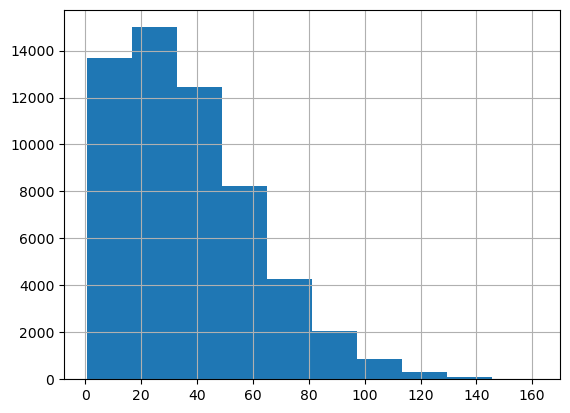

In [63]:
df["Risk_Safety_Interaction"].hist()

### Add a log-transformed version of the interaction.
Because risk interactions may grow exponentially rather than linearly.

In [64]:
# Add a log-transformed version of the interaction.
# Because risk interactions may grow exponentially rather than linearly.
df["Log_Risk_Safety"] = np.log1p(df["Risk_Safety_Interaction"])
df[["Risk_Safety_Interaction","Log_Risk_Safety"]].head()

,Risk_Safety_Interaction,Log_Risk_Safety
0,21.8316,3.128146
1,42.9536,3.783135
2,4.6055,1.723748
3,5.4945,1.870956
4,41.6717,3.753536


In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from xgboost import XGBClassifier


# Split features and target
X = df.drop("Target_Regulatory_Class", axis=1)
y = df["Target_Regulatory_Class"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Evaluation function
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))


# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=2.84,
    random_state=42,
    eval_metric="logloss"
)


# Train model
xgb_model.fit(X_train, y_train)


# Evaluate model
evaluate_model(xgb_model, X_test, y_test)

Accuracy : 0.7202631578947368
Recall   : 0.6933821084137014
Precision: 0.47909007352941174
F1 Score : 0.5666530778638402


algorithms and techniques used till here
| Model               | F1 Score  |
| ------------------- | --------- |
| Logistic Regression | 0.472     |
| Random Forest       | 0.466     |
| Logistic + SMOTE    | 0.519     |
| Threshold tuned     | 0.528     |
| Feature engineered  | 0.521     |
| **XGBoost**         | **0.567** |



Best selected model is: XGBoost

# Hyperparameter tuning

# RandomizedSearchCV

In [78]:
# from sklearn.model_selection import RandomizedSearchCV
# param_dist = {
#     "n_estimators": [200, 300, 400, 500],
#     "max_depth": [3, 4, 5, 6, 7, 8],
#     "learning_rate": [0.01, 0.03, 0.05, 0.1],
#     "subsample": [0.6, 0.8, 1.0],
#     "colsample_bytree": [0.6, 0.8, 1.0],
#     "gamma": [0, 0.1, 0.3, 0.5]
# } 
# xgb_random = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_dist,
#     n_iter=25,
#     scoring="f1",
#     cv=3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_random.fit(X_train, y_train)


In [79]:
xgb_random.best_params_

{'subsample': 0.6,
 'n_estimators': 400,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.5,
 'colsample_bytree': 1.0}

In [80]:
xgb_random.best_score_

np.float64(0.579006617023009)

In [83]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [250, 300, 350],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.02, 0.03, 0.05],
    "subsample": [0.5, 0.6, 0.7],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=2.84,
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.02, 0.03, 0.05],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [250, 300, 350],
                         'subsample': [0.5, 0.6, 0.7]},
             scoring='f1', verbose=2)

In [84]:
xgb_grid.best_params_

{'colsample_bytree': 0.7,
 'gamma': 0,
 'learning_rate': 0.02,
 'max_depth': 3,
 'n_estimators': 250,
 'subsample': 0.6}

In [85]:
xgb_grid.best_score_

np.float64(0.5798664561595753)

In [86]:
final_xgb = XGBClassifier(
    colsample_bytree=0.7,
    gamma=0.2,
    learning_rate=0.03,
    max_depth=4,
    n_estimators=250,
    subsample=0.7,
    scale_pos_weight=2.84,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(X_train, y_train)
y_pred_final = final_xgb.predict(X_test)

In [87]:
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Accuracy: 0.7087719298245614
Recall: 0.7213169271699368
Precision: 0.46635132229628035
F1 Score: 0.5664664403238443


# SHAP explainability

In [88]:
# !pip install shap

In [89]:
import shap
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test)


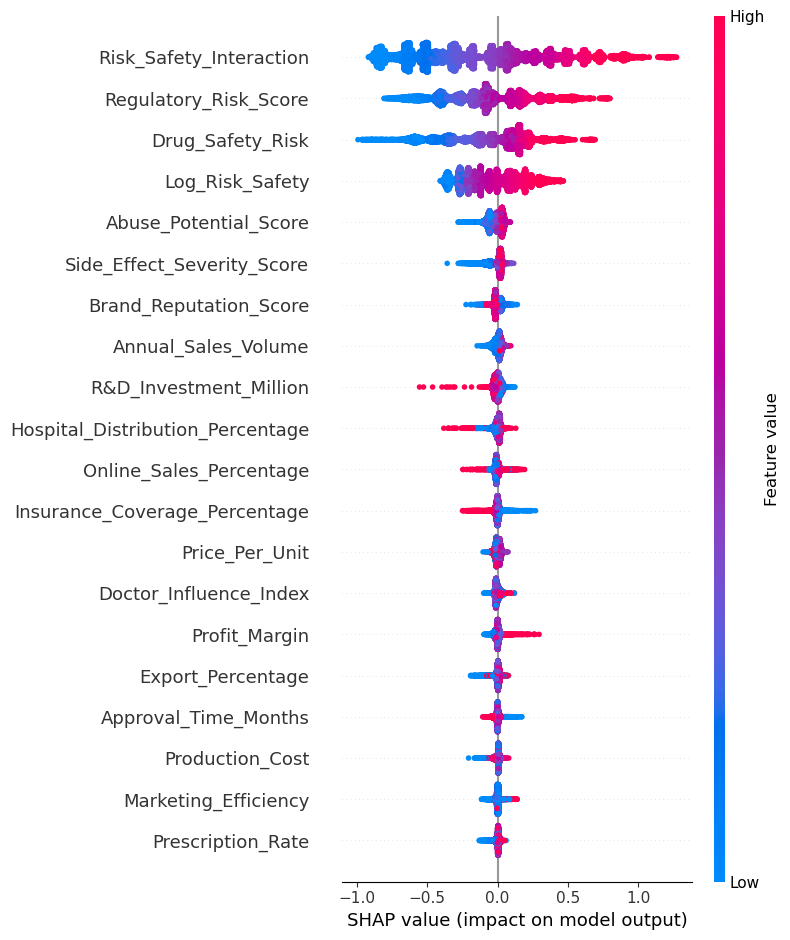

In [90]:
shap.summary_plot(shap_values, X_test)

In [91]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# list to store results
model_results = []

# evaluation function
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })


# Logistic Regression
evaluate_model("Logistic Regression", y_test, y_pred)

# Random Forest
evaluate_model("Random Forest", y_test, y_pred_rf)

# Logistic + SMOTE
evaluate_model("Logistic Regression + SMOTE", y_test, y_pred_smote)

# Threshold Tuning
evaluate_model("Threshold Tuned Model", y_test, y_pred_thresh)

# XGBoost
evaluate_model("XGBoost", y_test, y_pred_xgb)

# Final XGBoost (Tuned)
evaluate_model("Final XGBoost", y_test, y_pred_final)


# Convert results into DataFrame
results_df = pd.DataFrame(model_results)

# sort by best F1 score
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                         Model  Accuracy    Recall  Precision  F1 Score
5                Final XGBoost  0.708772  0.721317   0.466351  0.566466
4                      XGBoost  0.717456  0.693715   0.475604  0.564318
3        Threshold Tuned Model  0.673246  0.692052   0.426434  0.527704
2  Logistic Regression + SMOTE  0.623333  0.771201   0.391392  0.519257
0          Logistic Regression  0.779123  0.374460   0.638684  0.472117
1                Random Forest  0.776667  0.369471   0.630892  0.466023


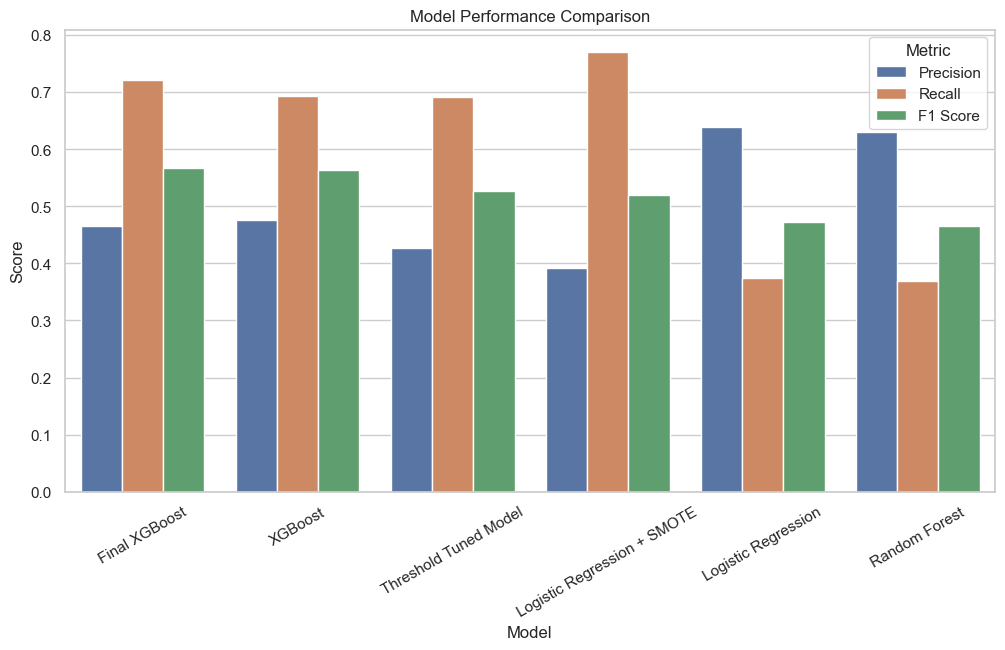

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Metric")

plt.show()

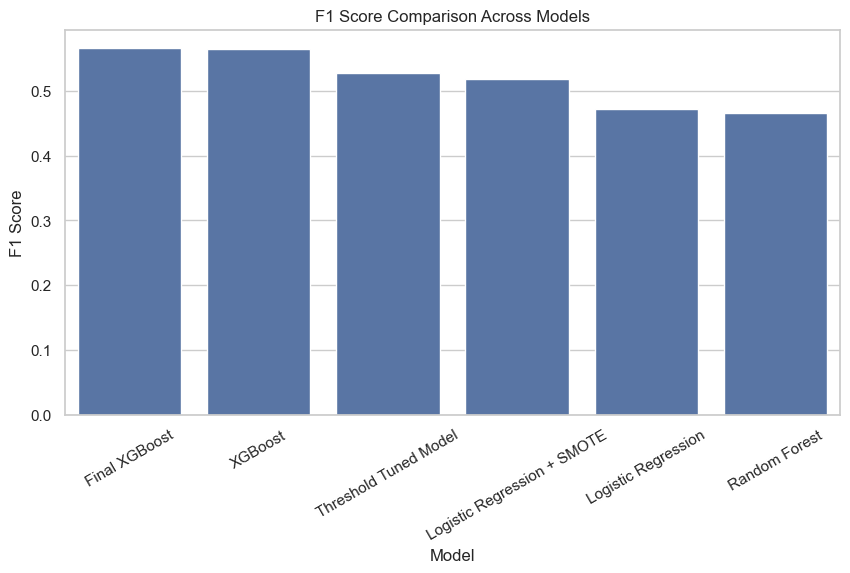

In [93]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison Across Models")
plt.xticks(rotation=30)

plt.show()

# Model deplopyment 

In [94]:
df.columns

Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Annual_Sales_Volume',
       'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance',
       'Insurance_Coverage_Percentage', 'Export_Percentage',
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate', 'Target_Regulatory_Class',
       'Profit_Margin', 'Drug_Safety_Risk', 'Drug_Form_Injection',
       'Drug_Form_Syrup', 'Drug_Form_Tablet', 'Therapeutic_Class_Antibiotic',
       'Therapeutic_Class_Antidepressant', 'Therapeutic_Class_Antiviral',
       'Therapeutic_Class_Cardiovascular', 'Manufacturing_Region_North',
       'Ma

In [95]:
import joblib

joblib.dump(final_xgb, "drug_regulation_model.pkl")

['drug_regulation_model.pkl']